In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder \
    .appName("BigDataSentimentAnalysis") \
    .getOrCreate()

In [ ]:
print(spark)

In [ ]:
print("Spark Version:", spark.version)

Spark Version: 4.0.2


In [ ]:
df = spark.read.csv(
    "/content/biodiversity_for_modelling.csv",
    header=True,
    inferSchema=True
)

In [ ]:
df.show(5)

+--------------------+--------------------+-------------+-----------+
|                  id|             keyword|    subdomain|final label|
+--------------------+--------------------+-------------+-----------+
|'1607463200697782273|                 dam|food security|   positive|
|'1587713755752067072|food self-suffici...|food security|   positive|
|'1549440716790992896|                 dam|food security|   positive|
|'1584195879073853440|                 dam|food security|    neutral|
|'1421620464166662145|        corona virus|       health|   negative|
+--------------------+--------------------+-------------+-----------+
only showing top 5 rows


In [ ]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- keyword: string (nullable = true)
 |-- subdomain: string (nullable = true)
 |-- final label: string (nullable = true)



In [ ]:
df.count()

13435

In [ ]:
df.columns

['id', 'keyword', 'subdomain', 'final label']

In [ ]:
df.describe().show()

+-------+--------------------+--------------------+--------------------+-----------+
|summary|                  id|             keyword|           subdomain|final label|
+-------+--------------------+--------------------+--------------------+-----------+
|  count|               13435|               13435|               13435|      13435|
|   mean|                NULL|                NULL|                NULL|       NULL|
| stddev|                NULL|                NULL|                NULL|       NULL|
|    min|'1135500783493963778|agricultural expa...|environmental man...|   negative|
|    max| '205532512984907776|    wildlife reserve|              health|   positive|
+-------+--------------------+--------------------+--------------------+-----------+



In [ ]:
print("Jumlah data awal:", df.count())

Jumlah data awal: 13435


In [ ]:
df_clean = df.dropna()

In [ ]:
df_clean = df_clean.dropDuplicates()

In [ ]:
print("Jumlah data setelah cleaning:", df_clean.count())

Jumlah data setelah cleaning: 13435


In [ ]:
df_env = df_clean.filter(
    df_clean["subdomain"] == "environmental management"
)

In [ ]:
df_env.show(5)

+--------------------+--------------+--------------------+-----------+
|                  id|       keyword|           subdomain|final label|
+--------------------+--------------+--------------------+-----------+
|'1388612100260569089|       recycle|environmental man...|   negative|
|'1214538837084426240|climate change|environmental man...|    neutral|
|'1461384441377406983| deforestation|environmental man...|   negative|
|'1571136735463211009|  electric car|environmental man...|   negative|
|'1486291014004674565|       recycle|environmental man...|   negative|
+--------------------+--------------+--------------------+-----------+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import concat_ws

In [ ]:
df_env = df_env.withColumn(
    "text",
    concat_ws(" ", df_env.keyword, df_env.subdomain)
)

In [ ]:
df_env.select("keyword", "subdomain", "text").show(5)

+--------------+--------------------+--------------------+
|       keyword|           subdomain|                text|
+--------------+--------------------+--------------------+
|       recycle|environmental man...|recycle environme...|
|climate change|environmental man...|climate change en...|
| deforestation|environmental man...|deforestation env...|
|  electric car|environmental man...|electric car envi...|
|       recycle|environmental man...|recycle environme...|
+--------------+--------------------+--------------------+
only showing top 5 rows


In [ ]:
print("Jumlah data environmental management:", df_env.count())

Jumlah data environmental management: 4316


In [ ]:
from pyspark.ml.feature import Tokenizer
from pyspark.ml.feature import StopWordsRemover
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.feature import IDF

In [ ]:
tokenizer = Tokenizer(
    inputCol="text",
    outputCol="words"
)

df_words = tokenizer.transform(df_env)

In [ ]:
df_words.select("text", "words").show(5, truncate=False)

+---------------------------------------+--------------------------------------------+
|text                                   |words                                       |
+---------------------------------------+--------------------------------------------+
|recycle environmental management       |[recycle, environmental, management]        |
|climate change environmental management|[climate, change, environmental, management]|
|deforestation environmental management |[deforestation, environmental, management]  |
|electric car environmental management  |[electric, car, environmental, management]  |
|recycle environmental management       |[recycle, environmental, management]        |
+---------------------------------------+--------------------------------------------+
only showing top 5 rows


In [ ]:
remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

df_filtered = remover.transform(df_words)

In [ ]:
df_filtered.select(
    "words",
    "filtered_words"
).show(5, truncate=False)

+--------------------------------------------+--------------------------------------------+
|words                                       |filtered_words                              |
+--------------------------------------------+--------------------------------------------+
|[recycle, environmental, management]        |[recycle, environmental, management]        |
|[climate, change, environmental, management]|[climate, change, environmental, management]|
|[deforestation, environmental, management]  |[deforestation, environmental, management]  |
|[electric, car, environmental, management]  |[electric, car, environmental, management]  |
|[recycle, environmental, management]        |[recycle, environmental, management]        |
+--------------------------------------------+--------------------------------------------+
only showing top 5 rows


In [ ]:
cv = CountVectorizer(
    inputCol="filtered_words",
    outputCol="rawFeatures"
)

cv_model = cv.fit(df_filtered)

df_featurized = cv_model.transform(df_filtered)

In [ ]:
idf = IDF(
    inputCol="rawFeatures",
    outputCol="features"
)

idf_model = idf.fit(df_featurized)

df_tfidf = idf_model.transform(df_featurized)

In [ ]:
df_tfidf.select(
    "filtered_words",
    "features"
).show(5, truncate=False)

+--------------------------------------------+--------------------------------------------------------------+
|filtered_words                              |features                                                      |
+--------------------------------------------+--------------------------------------------------------------+
|[recycle, environmental, management]        |(26,[0,1,11],[0.0,0.0,3.3731037217913626])                    |
|[climate, change, environmental, management]|(26,[0,1,7,8],[0.0,0.0,2.1069177329638538,2.1069177329638538])|
|[deforestation, environmental, management]  |(26,[0,1,18],[0.0,0.0,4.19592872565984])                      |
|[electric, car, environmental, management]  |(26,[0,1,2,3],[0.0,0.0,0.8769987466933326,1.3376917345274713])|
|[recycle, environmental, management]        |(26,[0,1,11],[0.0,0.0,3.3731037217913626])                    |
+--------------------------------------------+--------------------------------------------------------------+
only showi

In [ ]:
from pyspark.ml.feature import StringIndexer

In [ ]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="final label",
    outputCol="label"
)

df_label = label_indexer.fit(df_tfidf).transform(df_tfidf)

In [ ]:
df_label.select(
    "final label",
    "label"
).show(5)

+-----------+-----+
|final label|label|
+-----------+-----+
|   negative|  1.0|
|    neutral|  2.0|
|   negative|  1.0|
|   negative|  1.0|
|   negative|  1.0|
+-----------+-----+
only showing top 5 rows


In [ ]:
train_data, test_data = df_label.randomSplit([0.8, 0.2], seed=42)

In [ ]:
print("Jumlah data training:", train_data.count())
print("Jumlah data testing:", test_data.count())

Jumlah data training: 3502
Jumlah data testing: 814


In [ ]:
from pyspark.ml.classification import LogisticRegression

In [ ]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

In [ ]:
lr_model = lr.fit(train_data)

In [ ]:
predictions = lr_model.transform(test_data)

In [ ]:
predictions.select(
    "text",
    "final label",
    "prediction"
).show(10, truncate=False)

+---------------------------------------+-----------+----------+
|text                                   |final label|prediction|
+---------------------------------------+-----------+----------+
|forest fires environmental management  |neutral    |1.0       |
|climate change environmental management|negative   |1.0       |
|forest fires environmental management  |negative   |1.0       |
|climate change environmental management|negative   |1.0       |
|climate change environmental management|positive   |1.0       |
|climate change environmental management|negative   |1.0       |
|deforestation environmental management |negative   |1.0       |
|climate change environmental management|positive   |1.0       |
|climate change environmental management|negative   |1.0       |
|climate change environmental management|negative   |1.0       |
+---------------------------------------+-----------+----------+
only showing top 10 rows


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5233415233415234


In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.5233415233415234


In [ ]:
total_data = predictions.count()

print("Total data:", total_data)

Total data: 814


In [ ]:
from pyspark.sql.functions import col

In [ ]:
df_percentage = predictions.groupBy(
    "prediction"
).count()

In [ ]:
from pyspark.sql.functions import col

df_percentage = df_percentage.withColumn(
    "percentage",
    (col("count") / total_data) * 100
)

df_percentage.show()

+----------+-----+------------------+
|prediction|count|        percentage|
+----------+-----+------------------+
|       0.0|  495|60.810810810810814|
|       1.0|  306| 37.59213759213759|
|       2.0|   13| 1.597051597051597|
+----------+-----+------------------+



In [ ]:
df_percentage.orderBy(
    col("percentage").desc()
).show()

+----------+-----+------------------+
|prediction|count|        percentage|
+----------+-----+------------------+
|       0.0|  495|60.810810810810814|
|       1.0|  306| 37.59213759213759|
|       2.0|   13| 1.597051597051597|
+----------+-----+------------------+



In [ ]:
percentage_pandas = df_percentage.toPandas()

percentage_pandas

,prediction,count,percentage
0,0.0,495,60.810811
1,1.0,306,37.592138
2,2.0,13,1.597052


In [ ]:
import matplotlib.pyplot as plt

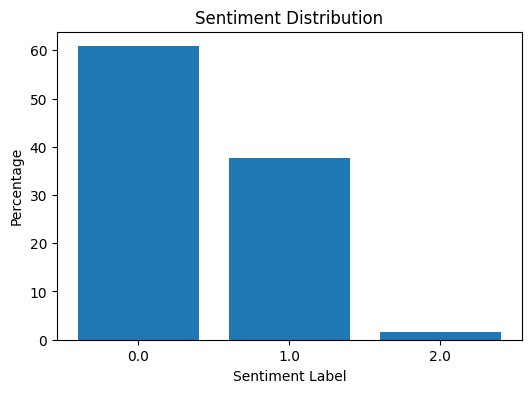

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    percentage_pandas["prediction"].astype(str),
    percentage_pandas["percentage"]
)

plt.xlabel("Sentiment Label")
plt.ylabel("Percentage")
plt.title("Sentiment Distribution")

plt.show()

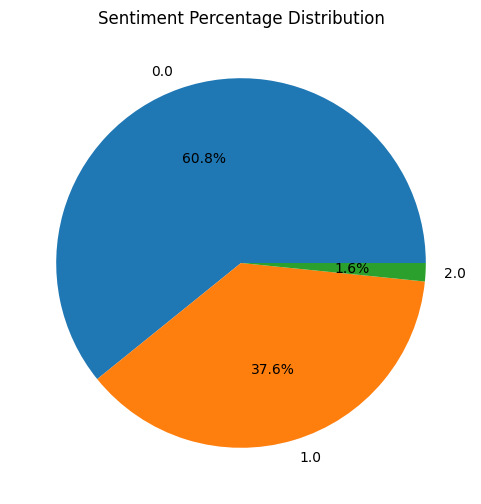

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    percentage_pandas["percentage"],
    labels=percentage_pandas["prediction"].astype(str),
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage Distribution")

plt.show()